In [46]:
from pathlib import Path
from collect_validation_results import collect_validation_results
import pandas as pd

## Load All Results

In [47]:
# Specify runs directory
runs_dir = Path("./runs")

# Collect all results (same format as notebook)
collected_results_summary, collected_validation_results = collect_validation_results(
    runs_dir=runs_dir,
    verbose=True,
    dataset_name="bdd100k_yolo",
)

print(f"\nLoaded {len(collected_results_summary)} results")
print(f"Models: {list(collected_validation_results.keys())}")

#add filter to select define models
defined_models = [] 

# defined_models = ["yolov8x", "yolov9e","yolov10x", "yolo11x","yolo12x"] 
defined_models = ["yolov8m","yolov8l","yolov8x", "yolov9c","yolov9e","yolov10x", "yolo11x","yolo12x"] 

# defined_models = ["yolov8s", "yolov9s", "yolov10s","yolo11s","yolo12s"] 

# defined_models = ["yolov8n", "yolov9t", "yolov10n","yolo11n","yolo12n"] 
# defined_models = ["yolov8n", "yolov9t", "yolov10n","yolo11n","yolo12n","yolov8s", "yolov9s", "yolov10s","yolo11s","yolo12s"] 
# defined_models = ["yolov8n", "yolov9t", "yolov10n","yolo11n","yolo12n","yolov8s", "yolov9s", "yolov10s","yolo11s","yolo12s","yolov8m","yolov8l","yolov8x"] 

# defined_models = [ "yolov8n", "yolov8s","yolov8m","yolov8l","yolov8x"]  


results_summary = [res for res in collected_results_summary if res["model_name"] in defined_models]
validation_results = {k: v for k, v in collected_validation_results.items() if k in defined_models}


# results_summary = [res for res in collected_results_summary if res["model_name"] not in defined_models]
# validation_results = {k: v for k, v in collected_validation_results.items() if k not in defined_models}



📁 Scanning 19 run directories...
✓ Loaded: yolo11n (Run: yolo11n_testing_20251124_003927)
✓ Loaded: yolo11s (Run: yolo11s_testing_20251124_012509)
✓ Loaded: yolo11x (Run: yolo11x_testing_20251124_000753)
✓ Loaded: yolo12n (Run: yolo12n_testing_20251124_004348)
✓ Loaded: yolo12s (Run: yolo12s_testing_20251124_013002)
✓ Loaded: yolo12x (Run: yolo12x_testing_20251124_005556)
✓ Loaded: yolov10n (Run: yolov10n_testing_20251124_003508)
✓ Loaded: yolov10s (Run: yolov10s_testing_20251124_012004)
✓ Loaded: yolov10x (Run: yolov10x_testing_20251123_234252)
✓ Loaded: yolov8l (Run: yolov8l_testing_20251123_225452)
✓ Loaded: yolov8m (Run: yolov8m_testing_20251123_224305)
✓ Loaded: yolov8n (Run: yolov8n_testing_20251123_223435)
✓ Loaded: yolov8s (Run: yolov8s_testing_20251123_223828)
✓ Loaded: yolov8x (Run: yolov8x_testing_20251123_230505)
✓ Loaded: yolov9c (Run: yolov9c_testing_20251123_233112)
✓ Loaded: yolov9e (Run: yolov9e_testing_20251124_014052)
✓ Loaded: yolov9s (Run: yolov9s_testing_20251124_

## View Results Summary as DataFrame

In [48]:
# Convert to DataFrame for easy viewing
# df_summary = pd.DataFrame(results_summary)
results_df = pd.DataFrame(results_summary)

results_df

,model_name,dataset,split,iou,precision_confusion,recall_confusion,f1_confusion,precision_yolo,recall_yolo,map50,map50_95,params_m,size_mb,fps,status,run_dir
0,yolo11x,bdd100k_yolo,test,0.5,0.323442,0.637974,0.429258,0.109850,0.132535,0.105072,0.063044,56.966176,109.325832,21.838612,ok,runs/yolo11x_testing_20251124_000753
1,yolo12x,bdd100k_yolo,test,0.5,0.304603,0.662510,0.417330,0.113202,0.112765,0.105022,0.063516,59.216928,113.791601,17.520907,ok,runs/yolo12x_testing_20251124_005556
2,yolov10x,bdd100k_yolo,test,0.5,0.311027,0.629308,0.416302,0.111305,0.097836,0.099722,0.060070,31.808960,61.411099,25.573293,ok,runs/yolov10x_testing_20251123_234252
3,yolov8l,bdd100k_yolo,test,0.5,0.314120,0.613333,0.415460,0.108815,0.119248,0.100817,0.059907,43.691520,83.724381,39.599258,ok,runs/yolov8l_testing_20251123_225452
4,yolov8m,bdd100k_yolo,test,0.5,0.311894,0.610726,0.412915,0.109914,0.108247,0.098763,0.057780,25.902640,49.720521,62.484066,ok,runs/yolov8m_testing_20251123_224305
5,yolov8x,bdd100k_yolo,test,0.5,0.325465,0.605396,0.423340,0.108540,0.120302,0.101862,0.060753,68.229648,130.547990,25.352577,ok,runs/yolov8x_testing_20251123_230505
6,yolov9c,bdd100k_yolo,test,0.5,0.309669,0.619463,0.412919,0.110395,0.106026,0.099582,0.058846,25.590912,49.395604,45.341054,ok,runs/yolov9c_testing_20251123_233112
7,yolov9e,bdd100k_yolo,test,0.5,0.331127,0.625583,0.433042,0.112195,0.121304,0.105743,0.063504,58.206592,112.074951,23.182243,ok,runs/yolov9e_testing_20251124_014052


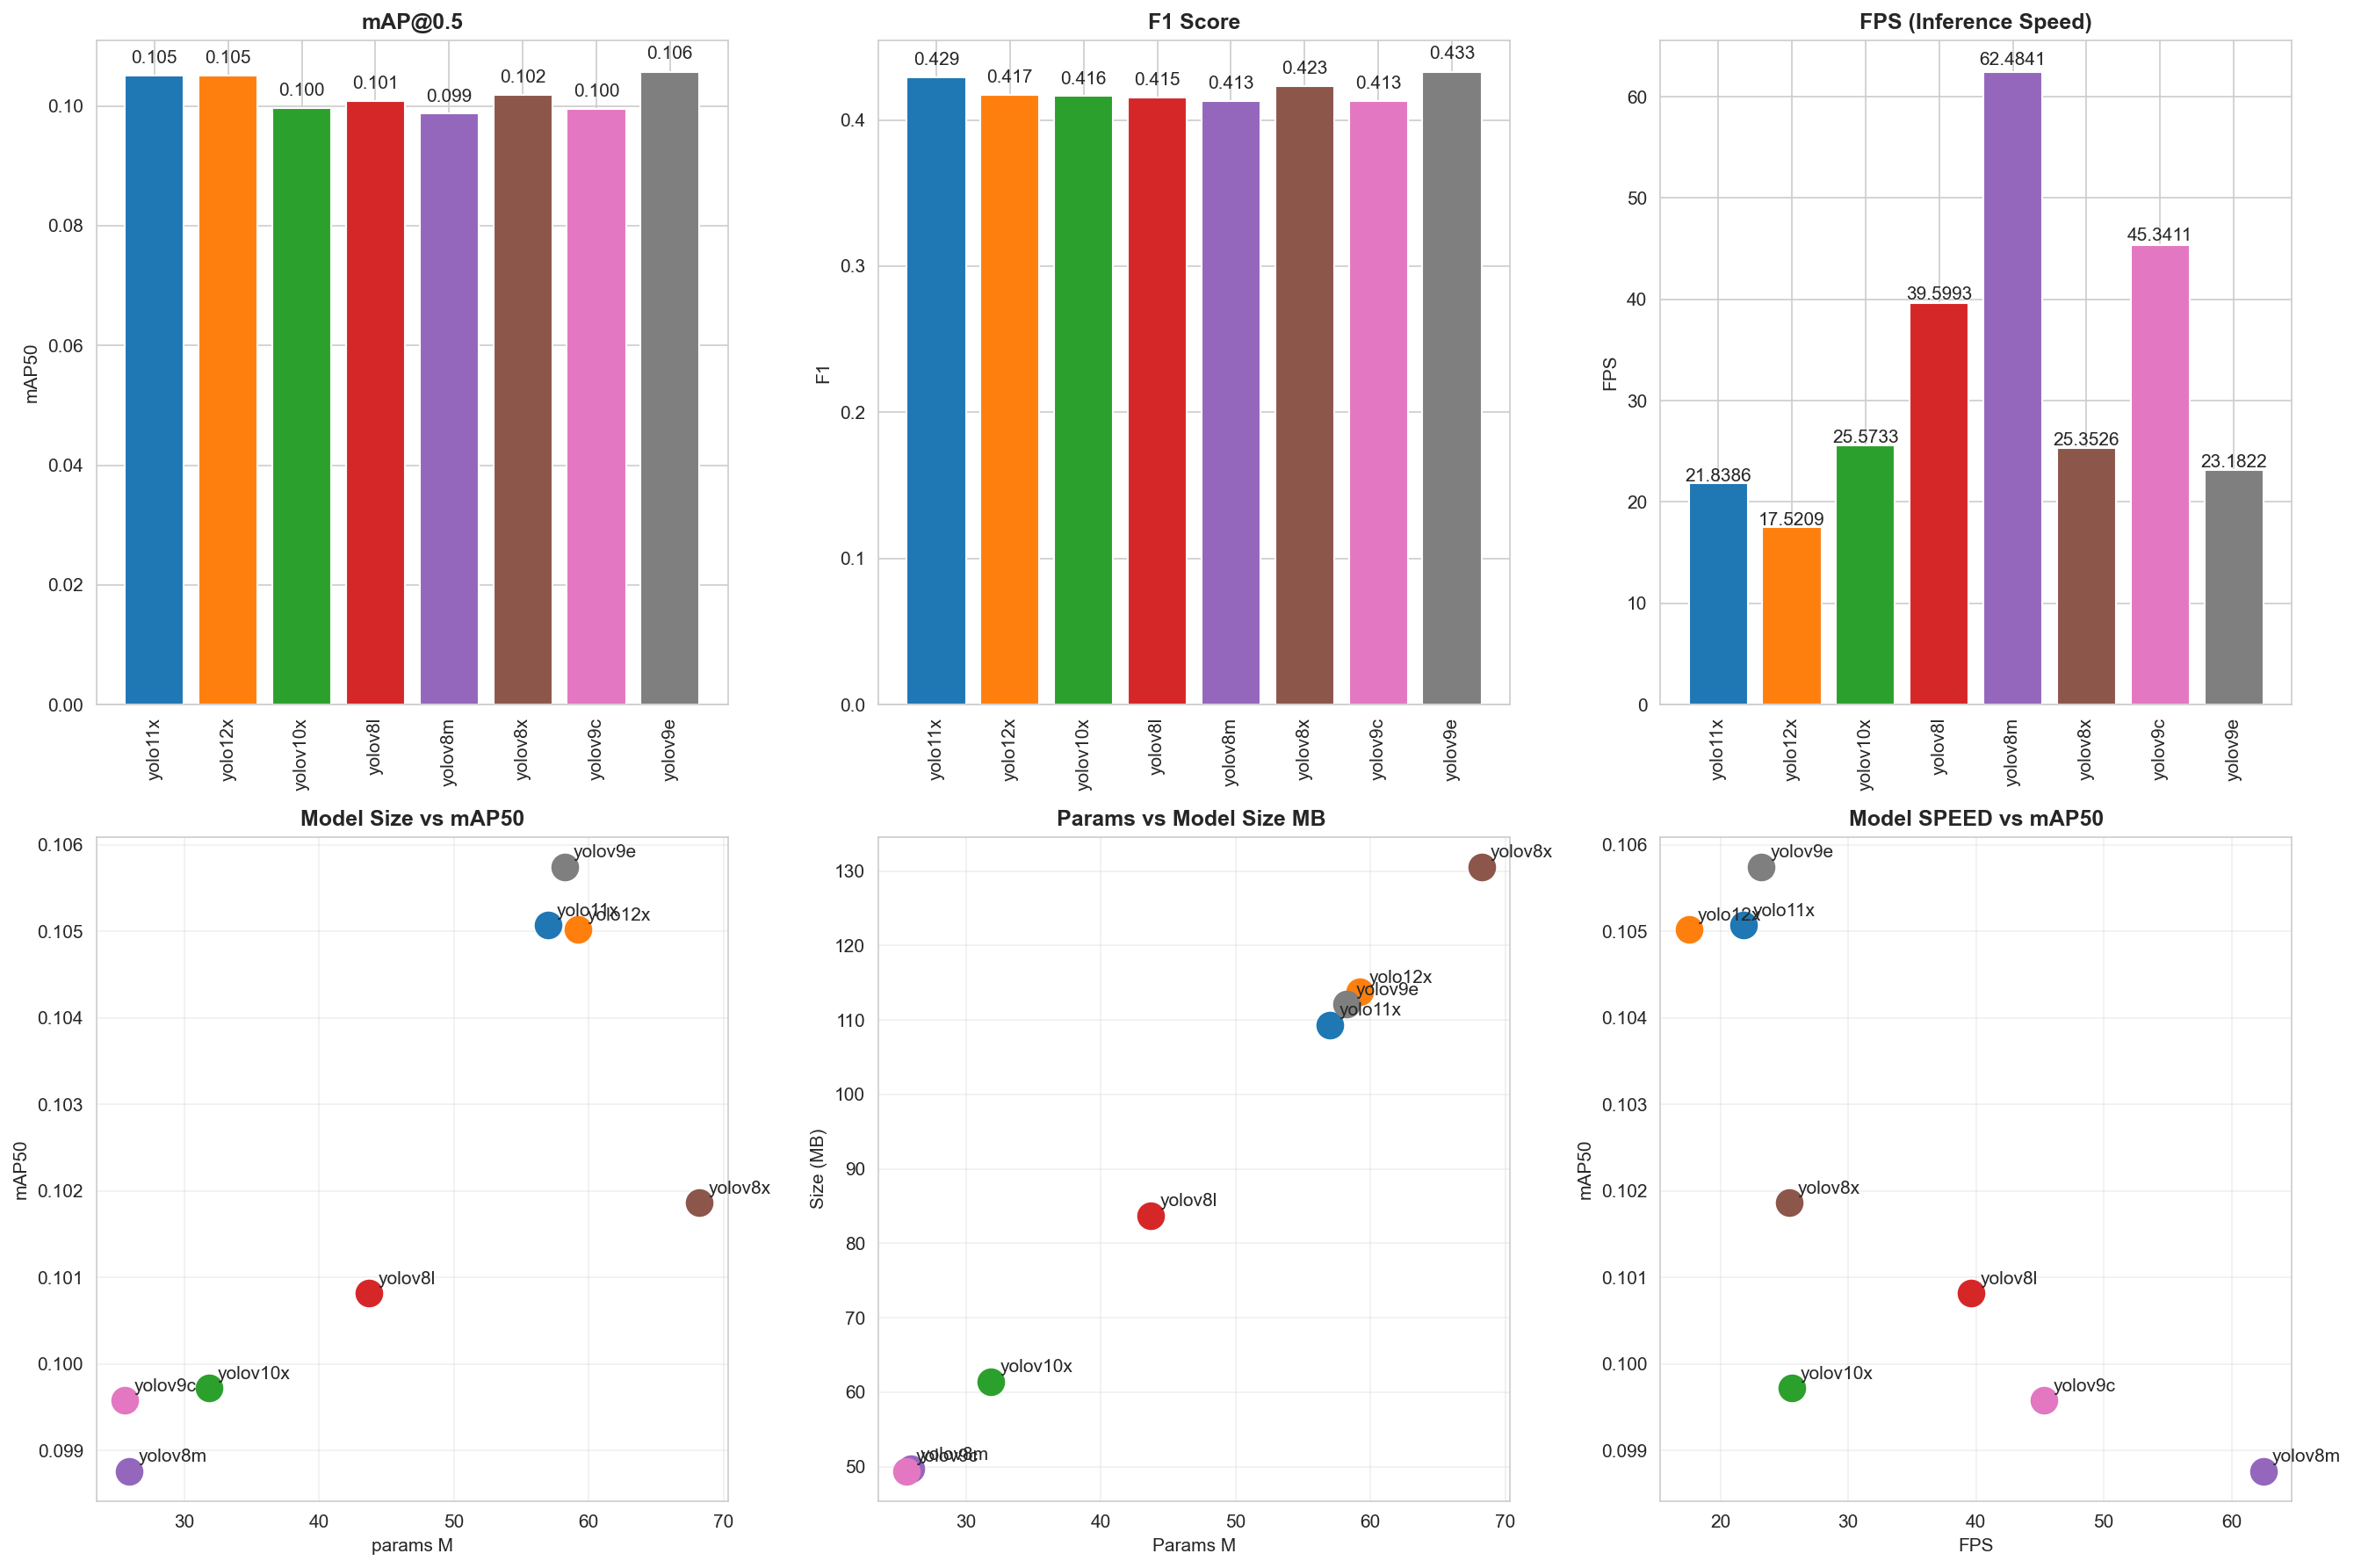

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

success_df = results_df[results_df["status"] == "ok"].copy()

# ---------------------------
# Assign stable colors
# ---------------------------
palette = sns.color_palette("tab10", len(success_df))
model_colors = {
    m: palette[i]
    for i, m in enumerate(success_df["model_name"])
}

models = success_df["model_name"].tolist()
colors = [model_colors[m] for m in models]

sns.set_style("whitegrid")
plt.close('all')

fig, axes = plt.subplots(2, 3, figsize=(18, 12), dpi=150)

# -----------------------------------
# 1) mAP@0.5
# -----------------------------------
axes[0,0].bar(models, success_df["map50"], color=colors)
axes[0,0].set_title("mAP@0.5", fontweight="bold")
axes[0,0].set_ylabel("mAP50")
axes[0,0].tick_params(axis='x', rotation=90)
for i, v in enumerate(success_df["map50"]):
    axes[0,0].text(i, v * 1.02, f"{v:.3f}", ha="center")

# -----------------------------------
# 2) F1 Score
# -----------------------------------
axes[0,1].bar(models, success_df["f1_confusion"], color=colors)
axes[0,1].set_title("F1 Score", fontweight="bold")
axes[0,1].set_ylabel("F1")
axes[0,1].tick_params(axis='x', rotation=90)
for i, v in enumerate(success_df["f1_confusion"]):
    axes[0,1].text(i, v * 1.02, f"{v:.3f}", ha="center")



# -----------------------------------
# 3) FPS (tiny values → use relative label placement)
# -----------------------------------
axes[0,2].bar(models, success_df["fps"], color=colors)
axes[0,2].set_title("FPS (Inference Speed)", fontweight="bold")
axes[0,2].set_ylabel("FPS")
axes[0,2].tick_params(axis='x', rotation=90)

for i, v in enumerate(success_df["fps"]):
    axes[0,2].text(i, v * 1.01, f"{v:.4f}", ha="center")
    
# -----------------------------------
# 4) Size vs Performance (scatter)
# -----------------------------------


for i, row in success_df.iterrows():
    axes[1,0].scatter(row["params_m"], row["map50"], 
                      s=200, color=model_colors[row["model_name"]])
    axes[1,0].annotate(row["model_name"],
                       (row["params_m"], row["map50"]),
                       xytext=(5, 5), textcoords="offset points")

axes[1,0].set_title("Model Size vs mAP50", fontweight="bold")
axes[1,0].set_xlabel("params M")
axes[1,0].set_ylabel("mAP50")
axes[1,0].grid(True, alpha=0.3)
    
# -----------------------------------
# 5) Size vs Performance (scatter)
# -----------------------------------
for i, row in success_df.iterrows():
    axes[1,1].scatter(row["params_m"], row["size_mb"], 
                      s=200, color=model_colors[row["model_name"]])
    axes[1,1].annotate(row["model_name"],
                       (row["params_m"], row["size_mb"]),
                       xytext=(5, 5), textcoords="offset points")

axes[1,1].set_title("Params vs Model Size MB ", fontweight="bold")
axes[1,1].set_xlabel("Params M")
axes[1,1].set_ylabel("Size (MB)")
axes[1,1].grid(True, alpha=0.3)
    
# -----------------------------------
# 6) FPS (tiny values → use relative label placement)
# -----------------------------------
for i, row in success_df.iterrows():
    axes[1,2].scatter(row["fps"], row["map50"], 
                      s=200, color=model_colors[row["model_name"]])
    axes[1,2].annotate(row["model_name"],
                       (row["fps"], row["map50"]),
                       xytext=(5, 5), textcoords="offset points")

axes[1,2].set_title("Model SPEED vs mAP50", fontweight="bold")
axes[1,2].set_xlabel("FPS")
axes[1,2].set_ylabel("mAP50")
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Per-Class Performance Comparison Across Models


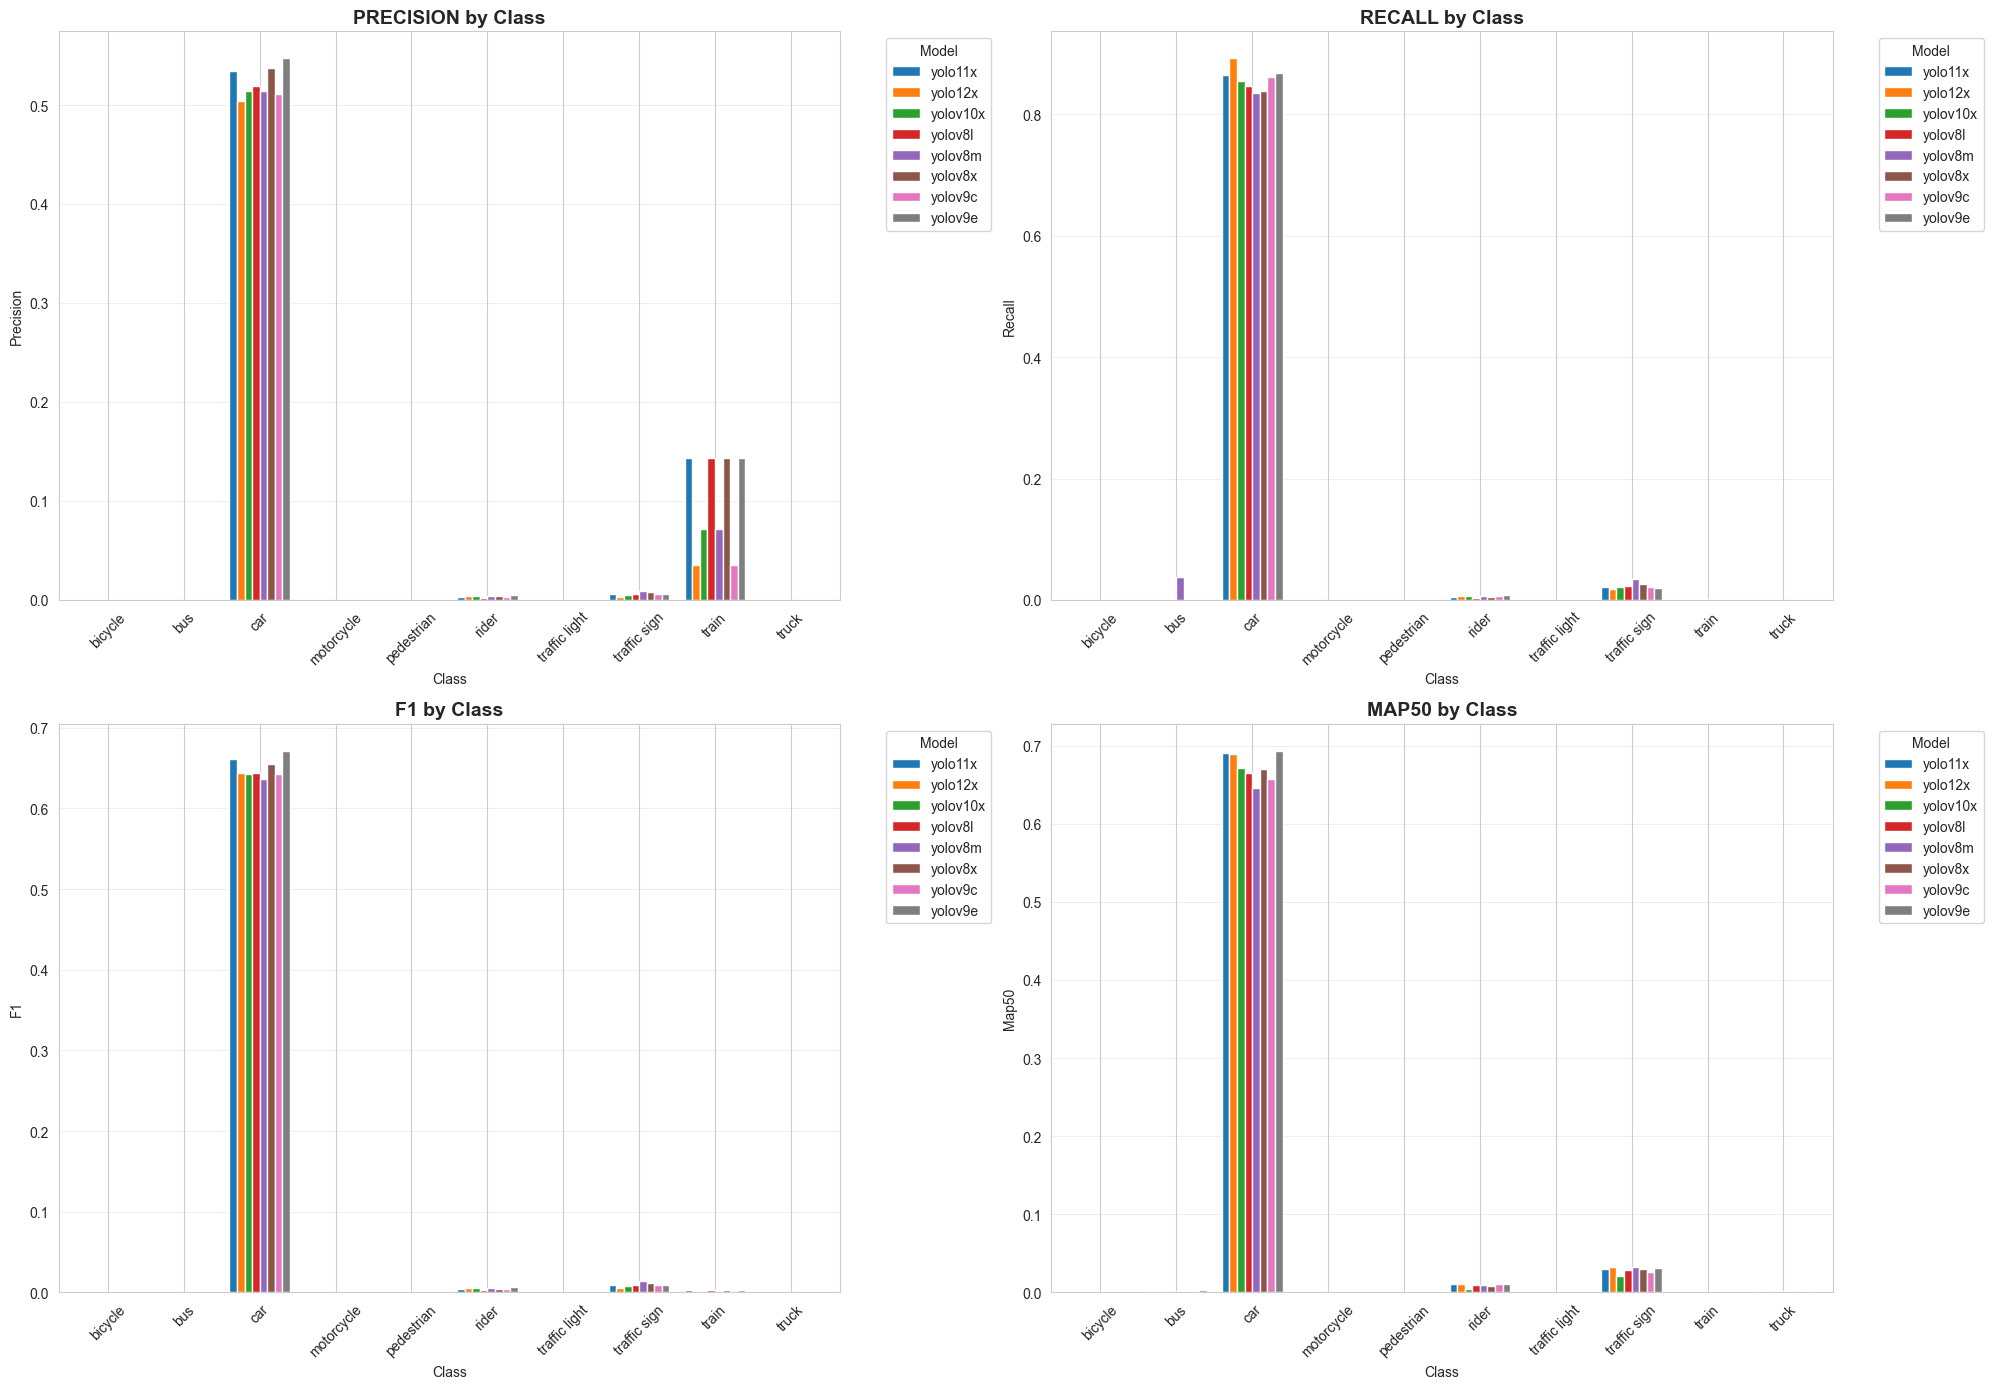


📊 Detailed Per-Class Metrics:
                   f1                                                   \
model         yolo11x yolo12x yolov10x yolov8l yolov8m yolov8x yolov9c   
class                                                                    
bicycle        0.0000  0.0000   0.0000  0.0000  0.0000  0.0000  0.0000   
bus            0.0000  0.0000   0.0000  0.0000  0.0006  0.0000  0.0000   
car            0.6608  0.6442   0.6420  0.6434  0.6366  0.6549  0.6420   
motorcycle     0.0000  0.0000   0.0000  0.0000  0.0000  0.0000  0.0000   
pedestrian     0.0000  0.0000   0.0000  0.0000  0.0000  0.0000  0.0000   
rider          0.0038  0.0049   0.0048  0.0029  0.0049  0.0045  0.0040   
traffic light  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000  0.0000   
traffic sign   0.0088  0.0057   0.0084  0.0097  0.0142  0.0119  0.0095   
train          0.0028  0.0007   0.0017  0.0029  0.0014  0.0025  0.0007   
truck          0.0000  0.0000   0.0000  0.0000  0.0000  0.0000  0.0000   

      

In [50]:
# 8. Per-Class Performance Comparison
if validation_results:
    print("=" * 80)
    print("Per-Class Performance Comparison Across Models")
    print("=" * 80)
    
    # Collect per-class data from the loaded JSON structure
    per_class_comparison = []
    for model_name, result in validation_results.items():
        # Access per_class metrics from the result structure
        per_class_metrics = result["metrics"]["per_class"]
        yolo_class_metrics = result["metrics"]["yolo_class_metrics"]
        
        for class_name, metrics in per_class_metrics.items():
            # Get mAP@0.5 from YOLO class metrics
            map50 = yolo_class_metrics.get(class_name, {}).get("ap50", 0.0)
            
            per_class_comparison.append({
                "model": model_name,
                "class": class_name,
                "precision": metrics.get("precision", 0.0),
                "recall": metrics.get("recall", 0.0),
                "f1": metrics.get("f1_score", 0.0),
                "map50": map50,
            })
    
    per_class_df = pd.DataFrame(per_class_comparison)
    
    # Get unique classes
    classes = per_class_df["class"].unique()
    
    # Plot comparison for each metric
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    
    for ax, metric in zip(axes.flatten(), ["precision", "recall", "f1", "map50"]):
        pivot_data = per_class_df.pivot(index="class", columns="model", values=metric)
        pivot_data.plot(kind="bar", ax=ax, width=0.8)
        ax.set_title(f"{metric.upper()} by Class", fontweight='bold', fontsize=14)
        ax.set_ylabel(metric.capitalize())
        ax.set_xlabel("Class")
        ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Display detailed table
    print("\n📊 Detailed Per-Class Metrics:")
    print(per_class_df.pivot_table(
        index="class",
        columns="model",
        values=["precision", "recall", "f1", "map50"],
        aggfunc="first"
    ).round(4))
else:
    print("No validation results available.")

In [51]:
# 9. Summary Report
print("=" * 80)
print("SUMMARY REPORT")
print("=" * 80)

if not results_df.empty:
    success_df = results_df[results_df["status"] == "ok"]
    
    if not success_df.empty:
        # Best model by different criteria
        best_map50 = success_df.loc[success_df["map50"].idxmax()]
        best_f1 = success_df.loc[success_df["f1_confusion"].idxmax()]
        best_fps = success_df.loc[success_df["fps"].idxmax()]
        smallest = success_df.loc[success_df["size_mb"].idxmin()]
        
        print("\n🏆 Best Model by mAP@0.5:")
        print(f"   {best_map50['model_name']} - mAP@0.5: {best_map50['map50']:.4f}")
        
        print("\n🏆 Best Model by F1 Score:")
        print(f"   {best_f1['model_name']} - F1: {best_f1['f1_confusion']:.4f}")
        
        print("\n⚡ Fastest Model:")
        print(f"   {best_fps['model_name']} - FPS: {best_fps['fps']:.2f}")
        
        print("\n📦 Smallest Model:")
        print(f"   {smallest['model_name']} - Size: {smallest['size_mb']:.1f} MB")
        
        print("\n" + "=" * 80)
        print("Detailed Comparison Table:")
        print("=" * 80)
        display(success_df[[
            "model_name", "map50", "map50_95", "f1_confusion",
            "precision_yolo", "recall_yolo", "params_m", "size_mb", "fps"
        ]].round(4))
    else:
        print("No successful runs to summarize.")
else:
    print("No results to display.")

SUMMARY REPORT

🏆 Best Model by mAP@0.5:
   yolov9e - mAP@0.5: 0.1057

🏆 Best Model by F1 Score:
   yolov9e - F1: 0.4330

⚡ Fastest Model:
   yolov8m - FPS: 62.48

📦 Smallest Model:
   yolov9c - Size: 49.4 MB

Detailed Comparison Table:


,model_name,map50,map50_95,f1_confusion,precision_yolo,recall_yolo,params_m,size_mb,fps
0,yolo11x,0.1051,0.0630,0.4293,0.1098,0.1325,56.9662,109.3258,21.8386
1,yolo12x,0.1050,0.0635,0.4173,0.1132,0.1128,59.2169,113.7916,17.5209
2,yolov10x,0.0997,0.0601,0.4163,0.1113,0.0978,31.8090,61.4111,25.5733
3,yolov8l,0.1008,0.0599,0.4155,0.1088,0.1192,43.6915,83.7244,39.5993
4,yolov8m,0.0988,0.0578,0.4129,0.1099,0.1082,25.9026,49.7205,62.4841
5,yolov8x,0.1019,0.0608,0.4233,0.1085,0.1203,68.2296,130.5480,25.3526
6,yolov9c,0.0996,0.0588,0.4129,0.1104,0.1060,25.5909,49.3956,45.3411
7,yolov9e,0.1057,0.0635,0.4330,0.1122,0.1213,58.2066,112.0750,23.1822
